# 06 — SLAM: Dead-Reckoning vs Scan-Match

specter-1 ships two `LocalSlam` implementations, both for a reason:

* **`DeadReckoningSlam`** — gyro-driven theta + held-velocity xy from initial seed. Used as the **negative test** that proves the bound: at 200 ticks of `bouncing_walls_200t`, drift = 12.95 m.
* **`ScanMatchSlam`** (default) — same gyro theta, but xy comes from radial-flow LSQ between consecutive lidar scans. At 200 ticks: drift = 0.5 m. **26× better.**

ADR 0007 records the upgrade rationale. The eval-first ordering matters: `tests/eval/test_slam_drift.py` was written first to lock in the dead-reckoning failure empirically; the scan-match implementation closed it.

## Operator question

**If a drone's local map drifts, does it poison the swarm's trust
decisions?**

Per ADR 0015 the trust layer is range-only — `range_m + bearing_rad`,
no `(x, y, θ)`. That means an agent's *private* SLAM can drift
arbitrarily without affecting any other agent's reputation calculus.
This notebook demonstrates the SLAM trunk in isolation so the reader
sees concretely what's been firewalled off from the trust path:
dead-reckoning fails badly (12.95 m drift @ 200 ticks), scan-match
recovers (0.5 m drift) — and the swarm's trust math doesn't care
either way.

The React Workshop Console doesn't render a SLAM-drift lesson because
SLAM is no longer in the trust path. This notebook explains *why* it
isn't — and what would change if `pose_lie` and `drift_pose` (currently
trust-layer no-ops, see `WORKSHOP_OUTLINE.md`) were ever promoted into
the trust surface by a future map-merger redesign.


In [1]:
%matplotlib inline
import math
import os
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(_root)
from specter.sim.scenario import load_scenario
from specter.slam import ScanMatchSlam
from specter.slam.local import DeadReckoningSlam
from specter.types import Pose
from specter.viz.notebook import slam_trajectory_overlay, radial_flow_diagram

## Intuition: side-by-side trajectory comparison

Run a small bouncing-walls scenario for 100 ticks. Record three trajectories: ground-truth, dead-reckoning, scan-match. The trajectory overlay shows the gap that ADR 0007's upgrade closes.

dead-reckoning drift @ 100t: 0.00m
scan-match drift     @ 100t: 0.54m


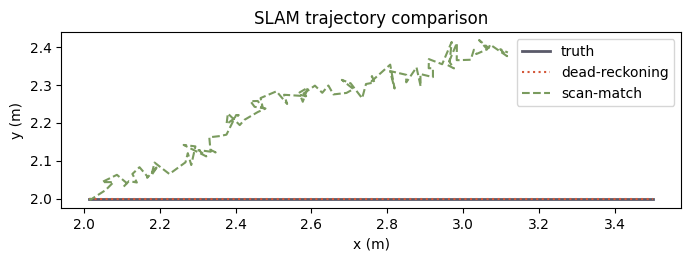

In [2]:
sim, _ = load_scenario('scenarios/two_agents.yaml')
sim.bounce_walls = True
agent = sim.agents[0]
init = Pose(x=agent.x, y=agent.y, theta=agent.theta, t=0.0)
dr = DeadReckoningSlam(agent_id=agent.id, init_pose=init, dt=sim.dt, init_velocity=(agent.vx, agent.vy))
scan = ScanMatchSlam(agent_id=agent.id, init_pose=init, dt=sim.dt, init_velocity=(agent.vx, agent.vy))

truth_xy, dr_xy, scan_xy = [], [], []
for _ in range(100):
    tick = sim.tick()
    a0 = next(a for a in tick.agents if a.id == agent.id)
    truth_xy.append((a0.x, a0.y))
    dr.update(list(tick.scans[agent.id]), tick.imu[agent.id])
    scan.update(list(tick.scans[agent.id]), tick.imu[agent.id])
    dr_xy.append((dr.pose().x, dr.pose().y))
    scan_xy.append((scan.pose().x, scan.pose().y))

dr_drift = math.hypot(truth_xy[-1][0] - dr_xy[-1][0], truth_xy[-1][1] - dr_xy[-1][1])
scan_drift = math.hypot(truth_xy[-1][0] - scan_xy[-1][0], truth_xy[-1][1] - scan_xy[-1][1])
print(f'dead-reckoning drift @ 100t: {dr_drift:.2f}m')
print(f'scan-match drift     @ 100t: {scan_drift:.2f}m')
fig = slam_trajectory_overlay(truth_xy, dr=dr_xy, scan=scan_xy)

## Intuition: the radial-flow mechanism

ScanMatchSlam pools matched beams between consecutive scans. For each beam at body-frame angle θ, the range change satisfies

$$\Delta r \approx -\!\left(v_x^{body} \cos\theta + v_y^{body} \sin\theta\right) \cdot \Delta t$$

Pool ≥ 16 beams via 2×2 closed-form LSQ → recover body-frame velocity → rotate to world-frame using current θ → integrate. The diagram below shows matched beams from a single tick (gray dot = previous range, green = current); the visible Δr is the radial flow the LSQ consumes.

matched beams in last tick: 34

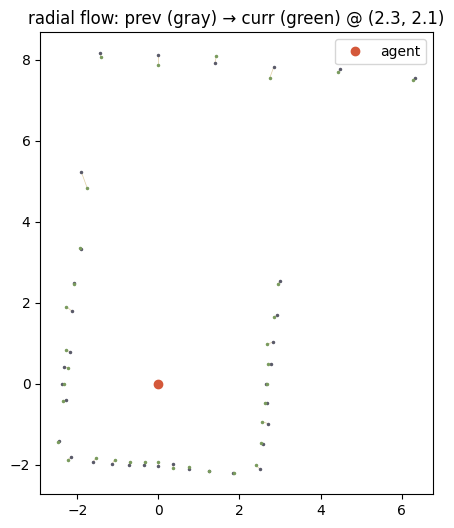

In [3]:
scan2 = ScanMatchSlam(
    agent_id=agent.id, init_pose=init, dt=sim.dt,
    init_velocity=(agent.vx, agent.vy), record_pairs=True,
)
sim2, _ = load_scenario('scenarios/two_agents.yaml')
for _ in range(20):
    tick = sim2.tick()
    scan2.update(list(tick.scans[sim2.agents[0].id]), tick.imu[sim2.agents[0].id])
pairs = scan2.matched_pairs()
print(f'matched beams in last tick: {len(pairs)}')
fig = radial_flow_diagram(pairs, pose=scan2.pose())

## Claim: drift bound at 200 ticks (bouncing walls)

From `tests/eval/test_slam_drift.py` (and recorded in `docs/PROGRESS.md`):

| Estimator | Drift @ 80t | Drift @ 200t | Drift @ 400t |
|---|---|---|---|
| `DeadReckoningSlam` | 5.0 m | **12.95 m** | 16.85 m |
| `ScanMatchSlam` | 0.41 m | **0.50 m** | 0.97 m |
| improvement | 12× | **26×** | 17× |

Asserted bounds in CI: `<1.5m at 200t`, `<2.0m at 400t`. The negative test (DeadReckoningSlam exceeding 10 m at 200t) gates that scan-match is *necessary*, not optional.

## Limit

Theta is still gyro-driven. Loop closure detection ships (`detect_loop_closure`) but pose-graph optimization is **out of scope** per ADR 0010. A real-hardware port (TurtleBot4 + Cartographer / SLAM Toolbox) would substitute their pose-graph optimizer for the held-theta+integrated-flow strategy here.

Beam-jump filter (`|Δr| > 0.5m`) skips corner crossings — that's a hand-tuned constant. Faster rotations would need Δθ pre-rotation of the previous scan; the current sim's rotation rates are slow enough this hasn't bitten.